In [2]:
import numpy as np 
import pandas as pd 
import tensorflow as tf
import matplotlib.pyplot as plt
import sklearn as sk 
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler    


In [14]:
data_0=pd.read_csv('AI_in_HealthCare_Dataset.csv')
data_0.head()
data_0.info()
data_0.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               5000 non-null   int64  
 1   Age                      5000 non-null   int64  
 2   Gender                   5000 non-null   object 
 3   Blood_Pressure           5000 non-null   float64
 4   Heart_Rate               5000 non-null   float64
 5   Temperature              5000 non-null   float64
 6   Diagnosis                5000 non-null   object 
 7   Medication               5000 non-null   object 
 8   Treatment_Duration       5000 non-null   int64  
 9   Insurance_Type           5000 non-null   object 
 10  Doctor_Name              5000 non-null   object 
 11  Hospital_Name            5000 non-null   object 
 12  Lab_Test_Results         5000 non-null   float64
 13  X-ray_Results            5000 non-null   object 
 14  Surgery_Type            

,Patient_ID,Age,Blood_Pressure,Heart_Rate,Temperature,Treatment_Duration,Lab_Test_Results,Recovery_Time,Patient_Satisfaction,AI_Diagnosis_Confidence
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,53.433200,119.863621,74.755327,98.603710,14.965400,100.201480,4.944200,2.993600,0.843927
std,1443.520003,20.931669,15.055656,9.974505,1.002509,8.403495,19.813474,2.570994,1.417731,0.084355
min,1.000000,18.000000,61.940115,36.760595,94.930131,1.000000,24.567602,1.000000,1.000000,0.700017
25%,1250.750000,35.000000,109.896065,67.935319,97.929791,8.000000,86.769592,3.000000,2.000000,0.768968
50%,2500.500000,53.000000,119.772157,75.000152,98.618301,15.000000,100.473921,5.000000,3.000000,0.843321
75%,3750.250000,72.000000,129.893989,81.556148,99.265743,22.000000,113.730522,7.000000,4.000000,0.917418
max,5000.000000,89.000000,168.092063,117.198456,102.497318,29.000000,168.340588,9.000000,5.000000,0.989988


In [4]:
data_0["Allergies"].isnull().sum()
data_0["Allergies"].fillna("NULL", inplace=True)
data_0["Allergies"].isnull().sum()
data_0.value_counts("Allergies")

/var/folders/yf/blbfthrd185738f9dyfzy7qw0000gn/T/ipykernel_1762/3922644047.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_0["Allergies"].fillna("NULL", inplace=True)


Allergies
Shellfish     1039
Latex         1034
Penicillin     994
Peanuts        969
NULL           964
Name: count, dtype: int64

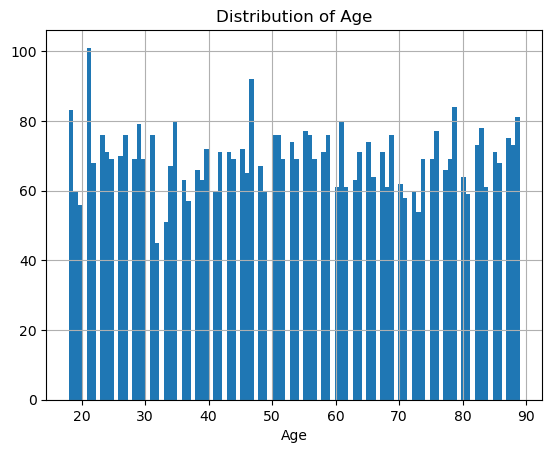

In [8]:
data_0.hist(column="Age", bins=100)
plt.xlabel("Age")
plt.title("Distribution of Age")
plt.show()

In [9]:
data_0['Gender'].value_counts()

Gender
Female    2535
Male      2465
Name: count, dtype: int64

In [13]:
print(data_0.value_counts("Allergies"))
print("===============================")
print(data_0.value_counts("Diagnosis"))
print("===============================")
print(data_0.value_counts("Medication"))
print("===============================")
print(data_0.value_counts("Insurance_Type"))
print("===============================")
print(data_0.value_counts("Doctor_Name"))
print("===============================")
print(data_0.value_counts("Hospital_Name"))
print("===============================")
print(data_0.value_counts("X-ray_Results"))

Allergies
Shellfish     1039
Latex         1034
Penicillin     994
Peanuts        969
NULL           964
Name: count, dtype: int64
Diagnosis
Heart Disease    1069
Cancer           1003
Diabetes         1003
Influenza         997
Hypertension      928
Name: count, dtype: int64
Medication
Aspirin         1021
Antibiotics     1020
Chemotherapy    1017
Statins          980
Insulin          962
Name: count, dtype: int64
Insurance_Type
Private      1295
Uninsured    1243
Medicaid     1234
Medicare     1228
Name: count, dtype: int64
Doctor_Name
Dr. Johnson    1018
Dr. Lee        1017
Dr. Smith       997
Dr. Wang        988
Dr. Brown       980
Name: count, dtype: int64
Hospital_Name
Children's Hospital    1028
City Medical Center    1018
Regional Hospital      1001
Healthcare Clinic       981
General Hospital        972
Name: count, dtype: int64
X-ray_Results
Abnormal    2509
Normal      2491
Name: count, dtype: int64


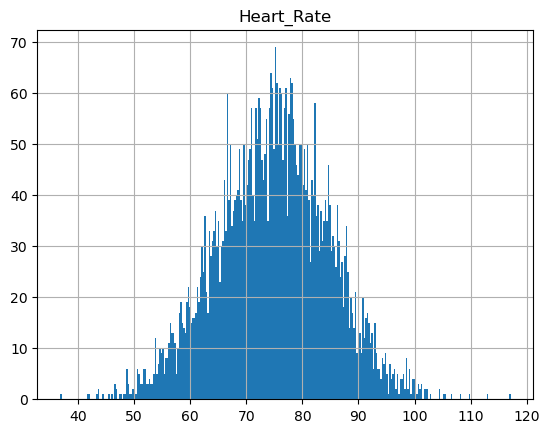

In [19]:
data_0.hist(column="Heart_Rate", bins=300)

plt.show()

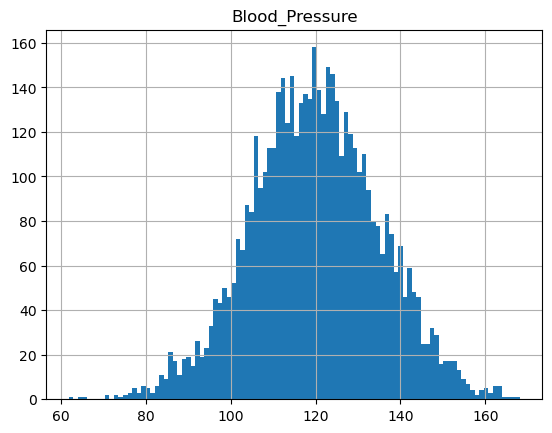

In [38]:
data_0.hist(column="Blood_Pressure", bins=100)

plt.show()

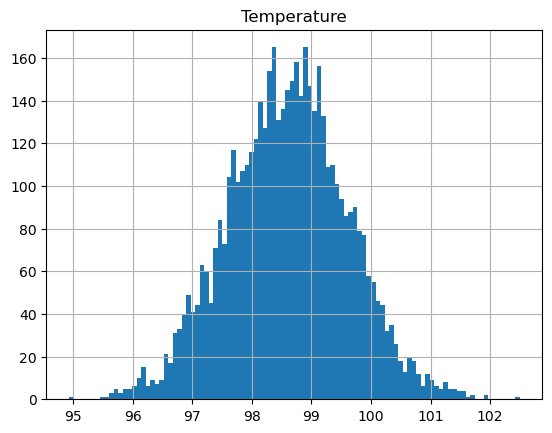

In [32]:
data_0.hist(column="Temperature", bins=100)

plt.show()

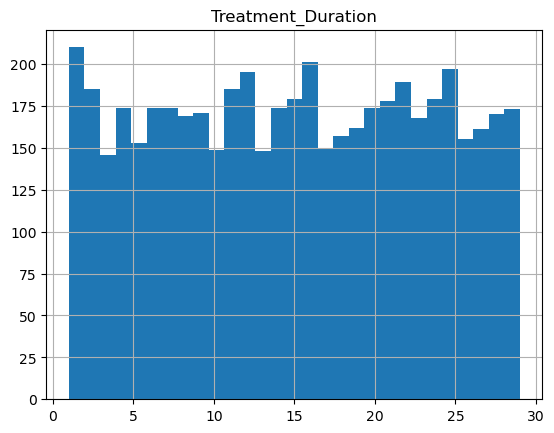

In [29]:
data_0.hist(column="Treatment_Duration", bins=29)

plt.show()

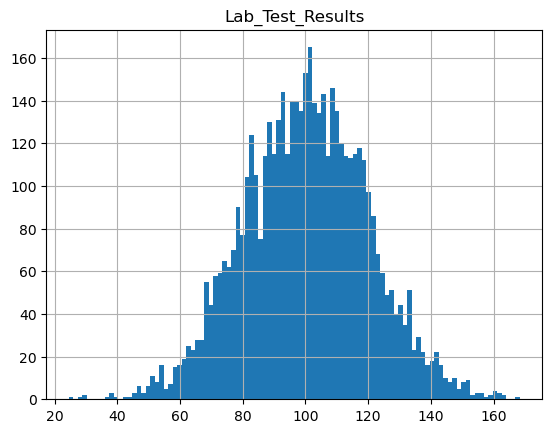

In [31]:
data_0.hist(column="Lab_Test_Results", bins=100)

plt.show()

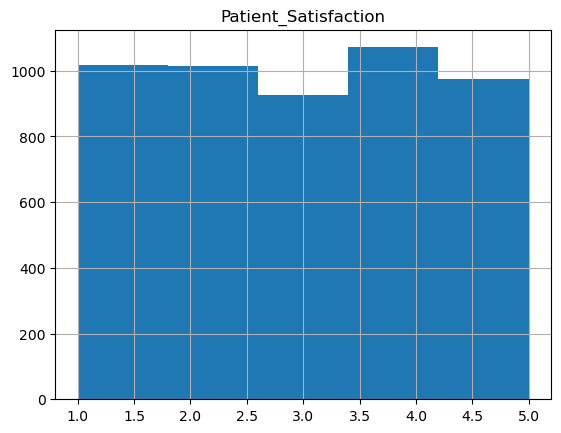

In [37]:
data_0.hist(column="Patient_Satisfaction", bins=5)

plt.show()